In [ ]:
# Install dependencies (run once per session)
%pip install pandas python-dateutil --quiet

import os
import tempfile
import pandas as pd
from datetime import datetime, timezone
from google.colab import drive
import ipaddress

# Mount Google Drive (interactive). This will prompt to authorize on first run.
drive.mount('/content/drive', force_remount=True)

# File paths
SAVE_PATH = "/content/drive/MyDrive/real_time_threat_data.csv"
FEATURES_PATH = "/content/drive/MyDrive/threat_features_fixed.csv"

# Canonical schema you expect
CANONICAL_COLS = ["timestamp", "ip", "note"]

# Ensure parent directory exists
parent = os.path.dirname(SAVE_PATH)
if parent and not os.path.exists(parent):
    os.makedirs(parent, exist_ok=True)

def safe_read_csv(path, cols):
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)
            # Ensure canonical columns exist
            for c in cols:
                if c not in df.columns:
                    df[c] = pd.NA
            # Optionally keep only canonical columns (uncomment if desired)
            # df = df[cols]
            return df
        except Exception as e:
            raise RuntimeError(f"Failed to read CSV {path}: {e}")
    else:
        return pd.DataFrame(columns=cols)

def atomic_to_csv(df, path):
    # Write to a temp file then atomically replace
    dirn = os.path.dirname(path) or "."
    fd, tmp_path = tempfile.mkstemp(prefix="tmp_threat_", dir=dirn, text=True)
    os.close(fd)
    try:
        df.to_csv(tmp_path, index=False)
        os.replace(tmp_path, path)  # atomic on most OS
    finally:
        if os.path.exists(tmp_path):
            try:
                os.remove(tmp_path)
            except Exception:
                pass

# Load existing file safely
threat_df = safe_read_csv(SAVE_PATH, CANONICAL_COLS)

# Build sample row
sample = {
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "ip": "1.2.3.4",
    "note": "example"
}

# Validate IP (raise if invalid)
try:
    ipaddress.ip_address(sample["ip"])
except Exception as e:
    raise ValueError(f"Invalid IP address in sample: {sample['ip']} ({e})")

# Append canonical-col DataFrame
row_df = pd.DataFrame([sample], columns=CANONICAL_COLS)
threat_df = pd.concat([threat_df, row_df], ignore_index=True)

# Save atomically
atomic_to_csv(threat_df, SAVE_PATH)

# Quick assertions for sanity (can remove in production)
assert os.path.exists(SAVE_PATH), "Failed to save CSV"
saved_last = pd.read_csv(SAVE_PATH).tail(1).iloc[0]
assert saved_last["ip"] == sample["ip"], "Saved last ip mismatch"

print("✅ Saved successfully at:", SAVE_PATH)
print(pd.read_csv(SAVE_PATH).tail(1))


Mounted at /content/drive
✅ Saved successfully at: /content/drive/MyDrive/real_time_threat_data.csv
    source                         timestamp content  ioc fetched_url  \
285    NaN  2025-12-03T06:46:27.284015+00:00     NaN  NaN         NaN   

    content_type       ip     note  
285          NaN  1.2.3.4  example  


In [ ]:
# Full balanced collector (fixed: verbose warnings suppressed, hostname checks, NameError fix)
%pip install pandas requests --quiet

import os, time, math, hashlib, re, tempfile, socket
from time import sleep
from datetime import datetime, timezone
from urllib.parse import urlparse, urljoin
import requests
import pandas as pd
from collections import deque
import ipaddress
import logging
from requests.adapters import HTTPAdapter
from requests.packages.urllib3.util.retry import Retry

# ---------------------
# Config (tune as needed)
# ---------------------
try:
    SAVE_PATH
except NameError:
    SAVE_PATH = "/content/drive/MyDrive/real_time_threat_data.csv"

CANONICAL_COLS = ["source", "timestamp", "content", "ioc", "fetched_url", "content_type"]

MIN_BENIGN = 100
MIN_MALICIOUS = 80
FINAL_TARGET = max(MIN_BENIGN, MIN_MALICIOUS)
MAX_RUNTIME = 15 * 60            # 15 minutes
LOOP_INTERVAL = 20
DELAY_BETWEEN_REQS = 0.3
REQUEST_TIMEOUT = 6
BENIGN_PER_DOMAIN = 2
MALICIOUS_IOC_FETCH_LIMIT = 100
PER_FEED_IOC_LIMIT = 50
MAL_CANDIDATE_TRIES = 3
MINIMAL_MAL_CONTENT = 150
FEED_CACHE_TTL = 120
DRY_RUN = False  # set True to test without writing files

DEFAULT_BENIGN_DOMAINS = [
    # Core safe web & tech domains
    "https://example.com",
    "https://www.python.org",
    "https://github.com",
    "https://wikipedia.org",
    "https://www.stackoverflow.com",
    "https://www.mozilla.org",
    "https://pypi.org",
    "https://numpy.org",
    "https://docs.python.org/3/",

    # Major global platforms
    "https://www.google.com",
    "https://www.youtube.com",
    "https://www.gmail.com",
    "https://www.google.co.in",
    "https://maps.google.com",
    "https://drive.google.com",
    "https://calendar.google.com",

    # Cloud providers
    "https://aws.amazon.com",
    "https://azure.microsoft.com",
    "https://cloud.google.com",
    "https://cloudflare.com",
    "https://digitalocean.com",

    # Developer & tech resources
    "https://developer.mozilla.org",
    "https://kaggle.com",
    "https://colab.research.google.com",
    "https://huggingface.co",
    "https://tensorflow.org",
    "https://pytorch.org",
    "https://anaconda.com",
    "https://scikit-learn.org",
    "https://matplotlib.org",

    # Social & communication platforms (commonly safe)
    "https://www.linkedin.com",
    "https://twitter.com",
    "https://x.com",
    "https://www.instagram.com",
    "https://www.facebook.com",
    "https://discord.com",
    "https://slack.com",
    "https://zoom.us",
    "https://teams.microsoft.com",

    # Software vendors
    "https://www.microsoft.com",
    "https://www.apple.com",
    "https://support.apple.com",
    "https://www.adobe.com",
    "https://www.oracle.com",

    # Learning platforms
    "https://www.coursera.org",
    "https://www.edx.org",
    "https://www.udemy.com",
    "https://www.khanacademy.org",
    "https://www.datacamp.com",

    # News & information
    "https://www.bbc.com",
    "https://www.cnn.com",
    "https://www.reuters.com",
    "https://www.theguardian.com",
    "https://news.ycombinator.com"
]


DEFAULT_MALICIOUS_FEEDS = {
    "MalwareBazaar": "https://bazaar.abuse.ch/export/csv/recent/",
    "ThreatFox": "https://threatfox.abuse.ch/export/csv/recent/",
    "URLHaus": "https://urlhaus.abuse.ch/downloads/csv_recent/",
    "PhishTank": "https://data.phishtank.com/data/online-valid.csv",
    "FeodoTracker": "https://feodotracker.abuse.ch/downloads/ipblocklist.csv"
}

HEADERS = {"User-Agent": "balanced-collect-bot/1.0 (+https://example.com)",
           "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8"}

BINARY_EXTS = {'.zip','.exe','.dll','.bin','.pdf','.doc','.docx','.xls','.xlsx','.7z','.tar','.gz','.iso','.apk'}

# ---------------------
# Logging/urllib3 quieting & helper
# ---------------------
logging.getLogger("urllib3").setLevel(logging.ERROR)  # hide retry warnings; keep errors visible

def now_iso():
    return datetime.now(timezone.utc).isoformat()

def content_hash(text: str):
    return hashlib.sha256(str(text or '').encode('utf-8')).hexdigest()

def ensure_parent_dir(path):
    d = os.path.dirname(path)
    if d and not os.path.exists(d):
        os.makedirs(d, exist_ok=True)

def safe_read_csv(path, cols):
    if os.path.exists(path):
        try:
            df = pd.read_csv(path, dtype=str).fillna('')
            for c in cols:
                if c not in df.columns:
                    df[c] = ''
            return df[cols]
        except Exception as e:
            print("⚠️ Could not read existing CSV:", e)
            return pd.DataFrame(columns=cols)
    else:
        return pd.DataFrame(columns=cols)

def atomic_to_csv(df, path):
    if DRY_RUN:
        print("[DRY RUN] Would save", len(df), "rows to", path)
        return
    ensure_parent_dir(path)
    fd, tmp = tempfile.mkstemp(prefix="tmp_threat_", dir=os.path.dirname(path) or ".")
    os.close(fd)
    try:
        df.to_csv(tmp, index=False)
        os.replace(tmp, path)
    finally:
        if os.path.exists(tmp):
            try: os.remove(tmp)
            except Exception: pass

def save_and_dedupe(df, path):
    df = df.copy()
    df['content'] = df['content'].astype(str).fillna('')
    df['fetched_url'] = df.get('fetched_url','').astype(str).fillna('')
    df['hash'] = (df['fetched_url'].fillna('') + '||' + df['content']).apply(content_hash)
    df = df.drop_duplicates(subset=['hash']).drop(columns=['hash'])
    atomic_to_csv(df, path)
    return df

def count_labels(df):
    if df.empty:
        return 0,0
    benign = int(df['source'].str.startswith('Benign:').sum())
    mal = int(df['source'].str.startswith('Malicious:').sum())
    return benign, mal

# ---------------------
# HTTP session with controlled retries (minimal)
# ---------------------
def new_session(headers=None, timeout=REQUEST_TIMEOUT, max_retries=0):
    s = requests.Session()
    s.headers.update(headers or HEADERS)
    retries = Retry(total=max_retries, backoff_factor=0.3, status_forcelist=[429,500,502,503,504])
    s.mount('http://', HTTPAdapter(max_retries=retries))
    s.mount('https://', HTTPAdapter(max_retries=retries))
    return s

# ---------------------
# IOC parsing + normalization
# ---------------------
RE_URL = re.compile(r"https?://[^\s,\"'<>]+", re.IGNORECASE)
RE_IP = re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b")
RE_DOMAIN = re.compile(r"\b(?:[a-z0-9](?:[a-z0-9-]{0,61}[a-z0-9])?\.)+[a-z]{2,}\b", re.IGNORECASE)

def is_probably_binary_path(path):
    p = (path or '').lower()
    for ext in BINARY_EXTS:
        if p.endswith(ext):
            return True
    return False

def normalize_and_validate_ioc(token):
    token = token.strip().strip('.,;\'"()[]<>')
    if not token:
        return None
    if token.startswith('http://') or token.startswith('https://'):
        try:
            parsed = urlparse(token)
            if not parsed.netloc:
                return None
            if is_probably_binary_path(parsed.path):
                return None
            return parsed.geturl()
        except Exception:
            return None
    try:
        ip = ipaddress.ip_address(token)
        return str(ip)
    except Exception:
        pass
    if '.' in token and len(token) > 3 and re.search(r'[a-zA-Z]', token):
        dom = token.lower()
        if any(c in dom for c in ' <>/"\''):
            return None
        if is_probably_binary_path(dom):
            return None
        return dom
    return None

def parse_iocs_from_text_strict(text):
    iocs = set()
    for m in RE_URL.finditer(text):
        v = normalize_and_validate_ioc(m.group(0))
        if v:
            iocs.add(v)
    for m in RE_IP.finditer(text):
        v = normalize_and_validate_ioc(m.group(0))
        if v:
            iocs.add(v)
    for m in RE_DOMAIN.finditer(text):
        v = normalize_and_validate_ioc(m.group(0))
        if v:
            iocs.add(v)
    return list(iocs)

# ---------------------
# Feed cache
# ---------------------
_feed_cache = {}  # name -> (timestamp, text)

def fetch_feed_text(session, name, feed_url, timeout=REQUEST_TIMEOUT):
    now = time.time()
    cached = _feed_cache.get(name)
    if cached and now - cached[0] < FEED_CACHE_TTL:
        return cached[1]
    try:
        r = session.get(feed_url, timeout=timeout)
        if r.status_code == 200 and r.text:
            _feed_cache[name] = (now, r.text)
            return r.text
    except Exception as e:
        print("feed fetch error:", name, e)
    return ''

# ---------------------
# Fetchers
# ---------------------
def fetch_benign_snapshots(domains, max_per_domain=1, delay=0.3, headers=None, timeout=REQUEST_TIMEOUT):
    session = new_session(headers=headers)
    rows = []
    for d in domains:
        urls_to_try = [d.rstrip("/")] + [urljoin(d, p) for p in ["/", "/index.html", "/about", "/robots.txt"]]
        count = 0
        for u in urls_to_try:
            if count >= max_per_domain:
                break
            try:
                r = session.get(u, timeout=timeout)
                if r.status_code == 200 and r.text and len(r.text) > 50:
                    rows.append({
                        "source": f"Benign:{urlparse(d).netloc or d}",
                        "timestamp": now_iso(),
                        "content": r.text,
                        "ioc": "",
                        "fetched_url": u,
                        "content_type": r.headers.get('Content-Type','')
                    })
                    print("✅ Collected benign snapshot:", u)
                    count += 1
            except Exception as e:
                print("benign fetch error:", u, e)
            sleep(delay)
    return rows

def safe_stream_text(session, url, timeout=4, max_bytes=200_000):
    try:
        r = session.get(url, timeout=timeout, stream=True)
        ct = r.headers.get('Content-Type', '').lower()
        if not any(t in ct for t in ('text','html','xml','json')):
            try: r.close()
            except: pass
            return None, ct
        chunks = []
        read = 0
        for chunk in r.iter_content(chunk_size=4096, decode_unicode=True):
            if chunk:
                chunks.append(chunk)
                read += len(chunk)
            if read >= max_bytes:
                break
        txt = ''.join(chunks)
        return txt, ct
    except Exception:
        return None, None

def seems_resolvable_hostname(hostname):
    if not hostname or '.' not in hostname or len(hostname) < 4 or len(hostname) > 255:
        return False
    try:
        socket.getaddrinfo(hostname, None)
        return True
    except Exception:
        return False

def fetch_malicious_by_following_iocs(feed_map, needed, per_feed_limit=PER_FEED_IOC_LIMIT, delay=0.05, headers=None, timeout=REQUEST_TIMEOUT):
    session = new_session(headers=headers)
    collected = []
    seen_iocs = set()
    total_attempts = 0
    for name, feed_url in feed_map.items():
        if total_attempts >= MALICIOUS_IOC_FETCH_LIMIT or len(collected) >= needed:
            break
        feed_text = fetch_feed_text(session, name, feed_url, timeout=timeout)
        if not feed_text:
            continue
        print(f"✅ Collected malicious feed: {name} ({len(feed_text)} bytes cached)")
        iocs = parse_iocs_from_text_strict(feed_text)[:per_feed_limit]
        for ioc in iocs:
            if len(collected) >= needed or total_attempts >= MALICIOUS_IOC_FETCH_LIMIT:
                break
            if ioc in seen_iocs:
                continue
            seen_iocs.add(ioc)
            total_attempts += 1
            candidates = []
            if ioc.startswith('http://') or ioc.startswith('https://'):
                candidates.append(ioc)
            else:
                candidates.append("https://" + ioc)
                candidates.append("http://" + ioc)
            for url in candidates[:MAL_CANDIDATE_TRIES]:
                parsed = urlparse(url)
                host = parsed.hostname
                if host and not seems_resolvable_hostname(host):
                    print("⏭️ Skipping unlikely hostname:", host)
                    continue
                txt, ct = safe_stream_text(session, url, timeout=4)
                if txt and len(txt) >= MINIMAL_MAL_CONTENT:
                    collected.append({
                        "source": f"Malicious:{name}",
                        "timestamp": now_iso(),
                        "content": txt,
                        "ioc": ioc,
                        "fetched_url": url,
                        "content_type": ct or ''
                    })
                    print("✅ Collected malicious sample from IoC:", url)
                    break
                if ct and not any(t in (ct or '') for t in ('text','html','xml','json')):
                    print("⏭️ Skipped non-text content-type for", url, ct)
                sleep(0.05)
            sleep(delay)
    return collected

# ---------------------
# Main loop
# ---------------------
def run_collector():
    start_time = time.time()
    existing = safe_read_csv(SAVE_PATH, CANONICAL_COLS)
    existing = save_and_dedupe(existing, SAVE_PATH)
    benign_cnt, mal_cnt = count_labels(existing)
    print(f"[{now_iso()}] ✅ Total entries so far: {len(existing)}  |  Benign: {benign_cnt}, Malicious: {mal_cnt}\n")

    iteration = 0
    recent_iters = deque(maxlen=5)

    while True:
        iteration += 1
        iter_start = time.time()
        elapsed_total = time.time() - start_time
        if elapsed_total >= MAX_RUNTIME:
            print("⏱️ Time limit reached — stopping collection.")
            break

        benign_cnt, mal_cnt = count_labels(existing)
        need_benign = max(0, FINAL_TARGET - benign_cnt)
        need_malicious = max(0, FINAL_TARGET - mal_cnt)

        if need_benign == 0 and need_malicious == 0:
            print("🎯 Targets reached — equalized dataset ready.")
            break

        print(f"--- Iteration {iteration} start [{now_iso()}] ---")
        print(f"⏳ Need Benign: {need_benign}, Need Malicious: {need_malicious} | elapsed {elapsed_total/60:.2f} min")

        benign_rows = []
        if need_benign > 0:
            domains_to_try = DEFAULT_BENIGN_DOMAINS[: max(1, min(len(DEFAULT_BENIGN_DOMAINS), math.ceil(need_benign / BENIGN_PER_DOMAIN)))]
            benign_rows = fetch_benign_snapshots(domains_to_try, max_per_domain=BENIGN_PER_DOMAIN, delay=DELAY_BETWEEN_REQS)

        mal_rows = []
        if need_malicious > 0:
            mal_rows = fetch_malicious_by_following_iocs(DEFAULT_MALICIOUS_FEEDS, needed=min(need_malicious, MALICIOUS_IOC_FETCH_LIMIT),
                                                         per_feed_limit=PER_FEED_IOC_LIMIT, delay=0.05)

        new_rows = []
        for r in (benign_rows + mal_rows):
            new_rows.append({
                "source": str(r.get("source","")),
                "timestamp": r.get("timestamp", now_iso()),
                "content": str(r.get("content","")),
                "ioc": str(r.get("ioc","")),
                "fetched_url": str(r.get("fetched_url","")),
                "content_type": str(r.get("content_type",""))
            })

        if new_rows:
            merged = pd.concat([existing, pd.DataFrame(new_rows, columns=CANONICAL_COLS)], ignore_index=True, sort=False)
            existing = save_and_dedupe(merged, SAVE_PATH)
        else:
            print("No new unique rows fetched this pass.")

        benign_cnt, mal_cnt = count_labels(existing)
        iter_end = time.time()
        iter_duration = iter_end - iter_start
        recent_iters.append(iter_duration)

        avg_iter = sum(recent_iters) / len(recent_iters) if recent_iters else iter_duration
        rem_samples = max(0, FINAL_TARGET - benign_cnt) + max(0, FINAL_TARGET - mal_cnt)
        samples_this_iter = max(1, len(new_rows))
        est_iters_needed = math.ceil(rem_samples / samples_this_iter) if samples_this_iter > 0 else 3
        est_secs_remaining = est_iters_needed * avg_iter
        est_mins = est_secs_remaining / 60.0

        print(f"[{now_iso()}] ✅ Total entries so far: {len(existing)}  ✅ Benign: {benign_cnt}, Malicious: {mal_cnt}")
        print(f"Iteration {iteration} duration: {iter_duration:.1f}s  |  Avg(recent) {avg_iter:.1f}s  |  ETA ≈ {est_mins:.1f} min\n")

        if time.time() - start_time >= MAX_RUNTIME:
            print("⏱️ Reached time cap during iteration — stopping.")
            break

        if need_benign > 0 or need_malicious > 0:
            seconds = min(LOOP_INTERVAL, max(5, int((MAX_RUNTIME - (time.time() - start_time)) / 6)))
            print(f"⏳ Waiting {seconds:.1f} seconds before next fetch...\n")
            sleep(seconds)
        else:
            break

    print("✅ Data collection finished (time-limited).")
    benign_cnt, mal_cnt = count_labels(existing)
    print(f"Final counts — Benign: {benign_cnt}, Malicious: {mal_cnt}")
    print("Saved CSV:", os.path.abspath(SAVE_PATH))

# Run
if __name__ == "__main__":
    run_collector()


[2025-12-03T06:46:46.794584+00:00] ✅ Total entries so far: 285  |  Benign: 100, Malicious: 100

🎯 Targets reached — equalized dataset ready.
✅ Data collection finished (time-limited).
Final counts — Benign: 100, Malicious: 100
Saved CSV: /content/drive/MyDrive/real_time_threat_data.csv


In [ ]:
# --- Freeze current threat dataset safely ---

import os
import pandas as pd
from datetime import datetime

# Ensure these match your previous code
SAVE_PATH = "/content/drive/MyDrive/real_time_threat_data.csv"
FREEZE_DIR = "/content/drive/MyDrive/frozen_datasets"

# 1️⃣ Load latest dataset
assert os.path.exists(SAVE_PATH), f"File not found: {SAVE_PATH}"
df = pd.read_csv(SAVE_PATH, dtype=str).fillna('')
print(f"📦 Loaded {len(df)} total rows from {SAVE_PATH}")

# 2️⃣ Basic cleanup (remove empty / invalid)
before = len(df)
df = df[df["content"].astype(str).str.len() > 100]  # keep only meaningful samples
df = df[df["source"].astype(str).str.len() > 0]     # ensure label source present
after = len(df)
print(f"🧹 Removed {before - after} empty or invalid rows. Final count: {after}")

# 3️⃣ Add canonical label column
df["label"] = df["source"].apply(lambda s: 1 if str(s).startswith("Malicious:") else 0)

# 4️⃣ Save frozen copy (timestamped)
os.makedirs(FREEZE_DIR, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
frozen_path = os.path.join(FREEZE_DIR, f"real_time_threat_data_frozen_{timestamp}.csv")

df.to_csv(frozen_path, index=False)
print(f"✅ Frozen snapshot saved at:\n{frozen_path}")

# 5️⃣ Optionally make a “latest frozen copy” symlink or copy
latest_copy = os.path.join(FREEZE_DIR, "real_time_threat_data_frozen_latest.csv")
df.to_csv(latest_copy, index=False)
print(f"📌 Also saved as latest frozen copy:\n{latest_copy}")

# 6️⃣ Quick sanity summary
print("\n🔍 Dataset summary:")
print(df["source"].str.extract(r"^(Benign|Malicious)")[0].value_counts())
print("\nColumns:", df.columns.tolist())


📦 Loaded 285 total rows from /content/drive/MyDrive/real_time_threat_data.csv
🧹 Removed 3 empty or invalid rows. Final count: 282
✅ Frozen snapshot saved at:
/content/drive/MyDrive/frozen_datasets/real_time_threat_data_frozen_20251203_064648.csv
📌 Also saved as latest frozen copy:
/content/drive/MyDrive/frozen_datasets/real_time_threat_data_frozen_latest.csv

🔍 Dataset summary:
0
Benign       100
Malicious     98
Name: count, dtype: int64

Columns: ['source', 'timestamp', 'content', 'ioc', 'fetched_url', 'content_type', 'label']


In [ ]:
import random, numpy as np, torch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [ ]:
import os, pandas as pd
path = "/content/drive/MyDrive/frozen_datasets/real_time_threat_data_frozen_latest.csv"
assert os.path.exists(path), f"Frozen file not found: {path}"
df = pd.read_csv(path, dtype=str).fillna('')
print("Rows:", len(df))
print(df.columns.tolist())
print(df['source'].value_counts())
# ensure content present
df = df[df['content'].str.len().fillna(0) > 50].reset_index(drop=True)
print("After removing tiny content:", len(df))


Rows: 282
['source', 'timestamp', 'content', 'ioc', 'fetched_url', 'content_type', 'label']
source
ThreatFox                       64
Malicious:ThreatFox             60
Benign:github.com               39
Benign:www.stackoverflow.com    24
Malicious:MalwareBazaar         23
MalwareBazaar                   16
Benign:stackoverflow.com        10
Benign:www.python.org            8
Malicious:PhishTank              7
Malicious:FeodoTracker           5
FeodoTracker                     4
Malicious:URLHaus                3
Benign:example.com               3
Benign:wikipedia.org             2
Benign:pypi.org                  2
Benign:www.fast.ai               2
Benign:www.djangoproject.com     2
Benign:www.tensorflow.org        2
Benign:realpython.com            2
Benign:www.mozilla.org           1
Benign:numpy.org                 1
Benign:docs.python.org/3         1
Benign:pytorch.org               1
Name: count, dtype: int64
After removing tiny content: 282


In [ ]:
!pip install beautifulsoup4 lxml --quiet
from bs4 import BeautifulSoup
def html_to_text(html):
    soup = BeautifulSoup(html, "lxml")
    # remove script/style
    for s in soup(["script","style","iframe","noscript"]):
        s.extract()
    text = soup.get_text(separator=" ")
    # collapse whitespace
    text = " ".join(text.split())
    return text

df['text'] = df['content'].apply(lambda x: html_to_text(x)[:200000])  # cap length


In [ ]:
df['text_len'] = df['text'].str.len()
df['text_len'].describe()


,text_len
count,282.000000
mean,72537.556738
std,90349.110103
min,0.000000
25%,3206.000000
50%,8253.000000
75%,200000.000000
max,200000.000000


In [ ]:
df['label'] = df['source'].apply(lambda s: 1 if str(s).startswith("Malicious:") else 0)
# keep only columns we care about
df = df[['timestamp','fetched_url','ioc','text','label']]


In [ ]:
df['text_clean'] = df['text'].str.lower()
# optional: remove weird long urls embedded - simple regex (customize as needed)
import re
df['text_clean'] = df['text_clean'].str.replace(r'https?://\S+','', regex=True)


In [ ]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=SEED)
train_df, val_df  = train_test_split(train_df, test_size=0.125, stratify=train_df['label'], random_state=SEED)
# result: ~70% train, 10% val, 20% test
print(len(train_df), len(val_df), len(test_df))


196 29 57


In [ ]:
for subset,name in [(train_df,"train"),(val_df,"val"),(test_df,"test")]:
    print(name, subset['label'].value_counts(normalize=False).to_dict())


train {0: 128, 1: 68}
val {0: 19, 1: 10}
test {0: 37, 1: 20}


In [ ]:
!pip install tensorflow --quiet
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib

MAX_VOCAB = 40000
MAX_LEN = 1024

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['text_clean'].tolist())
# convert
X_train_seq = tokenizer.texts_to_sequences(train_df['text_clean'])
X_val_seq   = tokenizer.texts_to_sequences(val_df['text_clean'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['text_clean'])
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

joblib.dump(tokenizer, "/content/drive/MyDrive/threat_tokenizer.joblib")
import numpy as np
np.save("/content/drive/MyDrive/threat_X_train.npy", X_train_pad)
np.save("/content/drive/MyDrive/threat_y_train.npy", train_df['label'].values)
# same for val/test


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPool1D, Dense, Dropout
model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPool1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile('adam', loss='binary_crossentropy', metrics=['AUC'])
model.summary()
# train: model.fit(X_train_pad, y_train, validation_data=(X_val_pad,y_val), epochs=5, batch_size=32)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
cw = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weight = {i: v for i,v in enumerate(cw)}
# pass to model.fit(class_weight=class_weight) in Keras or use sample_weight


In [ ]:
import json
cfg = {
  "seed": SEED,
  "max_len": MAX_LEN,
  "max_vocab": MAX_VOCAB,
  "tfidf_max_features": 50000
}
with open("/content/drive/MyDrive/preproc_config.json","w") as f:
    json.dump(cfg, f, indent=2)


In [ ]:
def pct_oov(tokenizer, texts):
    seqs = tokenizer.texts_to_sequences(texts)
    total = sum(len(s) for s in seqs)
    oov = sum(1 for s in seqs for t in s if t == tokenizer.word_index.get(tokenizer.oov_token, None))
    return oov/total if total else 0
print("Val OOV rate:", pct_oov(tokenizer, val_df['text_clean'].tolist()))


Val OOV rate: 0.01191596111633741


In [ ]:
import hashlib
df['content_hash'] = df['text'].apply(lambda t: hashlib.sha256(t.encode('utf-8')).hexdigest())
df[['timestamp','fetched_url','ioc','content_hash','label']].to_csv("/content/drive/MyDrive/threat_metadata.csv", index=False)


In [ ]:
# --- Exploratory Data Analysis (EDA) for Frozen Threat Dataset ---
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import seaborn as sns
from bs4 import BeautifulSoup
import re
from sklearn.feature_extraction.text import CountVectorizer

# Path to your frozen dataset
DATA_PATH = "/content/drive/MyDrive/frozen_datasets/real_time_threat_data_frozen_latest.csv"

# 1️⃣ Load dataset
assert os.path.exists(DATA_PATH), f"Frozen dataset not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH, dtype=str).fillna('')
print(f"✅ Loaded {len(df)} rows")
print(df.columns.tolist())
df.head(3)

# 2️⃣ Create label column (0=Benign, 1=Malicious)
df['label'] = df['source'].apply(lambda s: 1 if str(s).startswith("Malicious:") else 0)
print(df['label'].value_counts())

# 3️⃣ Clean minimal text for analysis (strip HTML)
def html_to_text(html):
    soup = BeautifulSoup(html, "lxml")
    for s in soup(["script", "style", "iframe", "noscript"]):
        s.extract()
    text = soup.get_text(" ")
    return re.sub(r'\s+', ' ', text.strip())

df['text'] = df['content'].apply(lambda x: html_to_text(x))
df['text_len'] = df['text'].str.len()


✅ Loaded 282 rows
['source', 'timestamp', 'content', 'ioc', 'fetched_url', 'content_type', 'label']
label
0    184
1     98
Name: count, dtype: int64


/tmp/ipython-input-914474605.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='coolwarm')


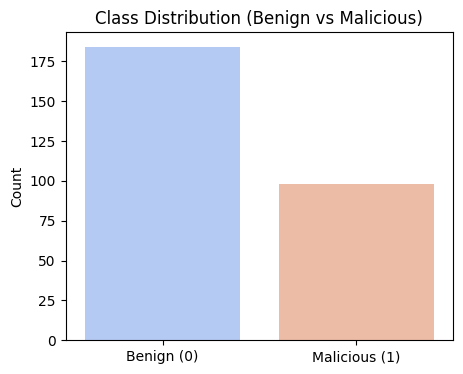

In [ ]:
# -------------------------------
# ⚖️ Class balance visualization
# -------------------------------
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df, palette='coolwarm')
plt.title('Class Distribution (Benign vs Malicious)')
plt.xticks([0,1], ['Benign (0)', 'Malicious (1)'])
plt.xlabel('')
plt.ylabel('Count')
plt.show()


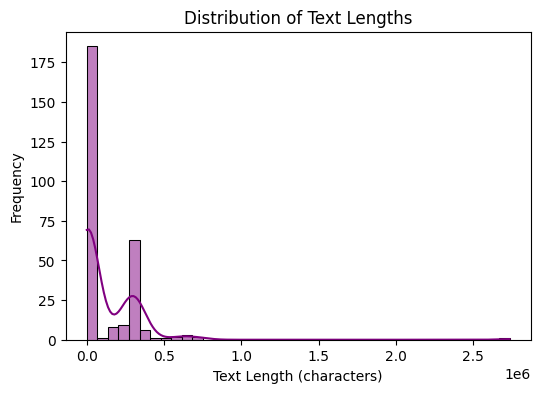

Text length summary (chars):
       count           mean            std    min     25%      50%        75%  \
label                                                                           
0      184.0  144463.690217  171577.044736  142.0  8253.0  22339.5  283582.50   
1       98.0   80924.500000  295177.749883    0.0   369.0   2594.0    6276.25   

             max  
label             
0       739470.0  
1      2733605.0  


In [ ]:
# -------------------------------
# ✍️ Text length analysis
# -------------------------------
plt.figure(figsize=(6,4))
sns.histplot(df['text_len'], bins=40, kde=True, color='purple')
plt.title("Distribution of Text Lengths")
plt.xlabel("Text Length (characters)")
plt.ylabel("Frequency")
plt.show()

print("Text length summary (chars):")
print(df.groupby('label')['text_len'].describe())

       count          mean           std   min     25%     50%      75%  \
label                                                                     
0      184.0  10172.711957  10150.814031  21.0  1219.0  3753.0  22335.5   
1       98.0   6989.193878  27974.197432   0.0    55.0   232.0    966.0   

            max  
label            
0       27844.0  
1      265355.0  


/tmp/ipython-input-1880109696.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='word_count', data=df, palette='Set2')


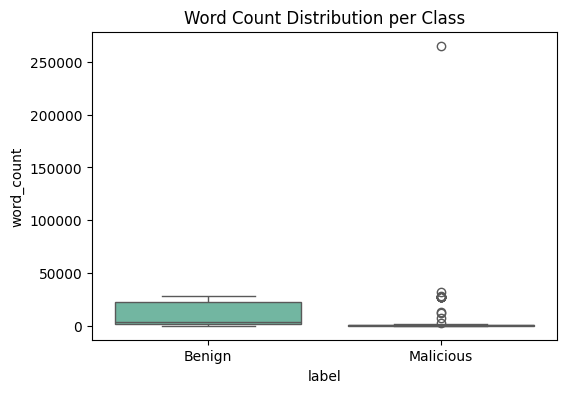

In [ ]:
# -------------------------------
# 🔡 Word count & average words
# -------------------------------
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
print(df.groupby('label')['word_count'].describe())

plt.figure(figsize=(6,4))
sns.boxplot(x='label', y='word_count', data=df, palette='Set2')
plt.title("Word Count Distribution per Class")
plt.xticks([0,1], ['Benign', 'Malicious'])
plt.show()


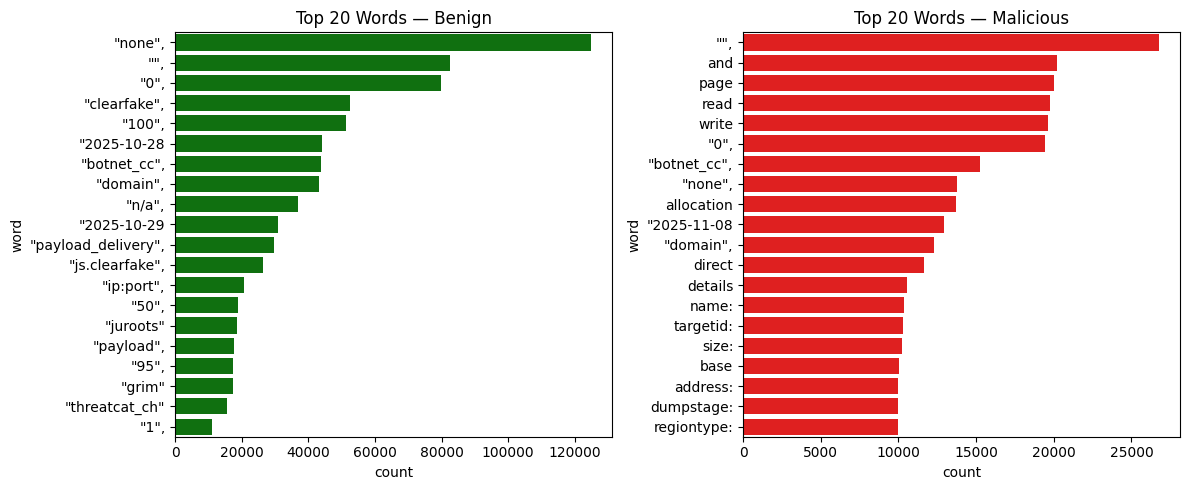

In [ ]:
# -------------------------------
# 🔠 Top frequent words per class
# -------------------------------
def top_words(texts, n=20):
    words = Counter(" ".join(texts).lower().split())
    return pd.DataFrame(words.most_common(n), columns=['word','count'])

ben_top = top_words(df[df.label==0]['text'])
mal_top = top_words(df[df.label==1]['text'])

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.barplot(y='word', x='count', data=ben_top, ax=axes[0], color='green')
axes[0].set_title("Top 20 Words — Benign")
sns.barplot(y='word', x='count', data=mal_top, ax=axes[1], color='red')
axes[1].set_title("Top 20 Words — Malicious")
plt.tight_layout()
plt.show()


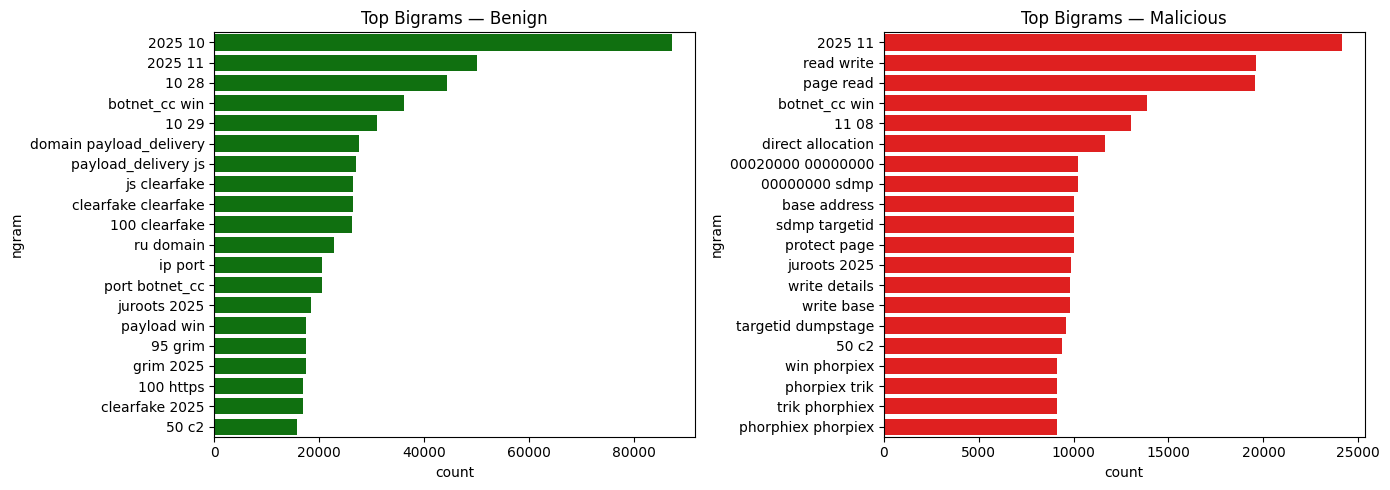

In [ ]:
# -------------------------------
# 🔍 N-gram comparison
# -------------------------------
def top_ngrams(corpus, ngram_range=(2,2), n=20):
    vec = CountVectorizer(stop_words='english', ngram_range=ngram_range, max_features=5000)
    bag = vec.fit_transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]
    return pd.DataFrame(words_freq, columns=['ngram','count'])

ben_bigrams = top_ngrams(df[df.label==0]['text'])
mal_bigrams = top_ngrams(df[df.label==1]['text'])

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(y='ngram', x='count', data=ben_bigrams, ax=axes[0], color='green')
axes[0].set_title("Top Bigrams — Benign")
sns.barplot(y='ngram', x='count', data=mal_bigrams, ax=axes[1], color='red')
axes[1].set_title("Top Bigrams — Malicious")
plt.tight_layout()
plt.show()

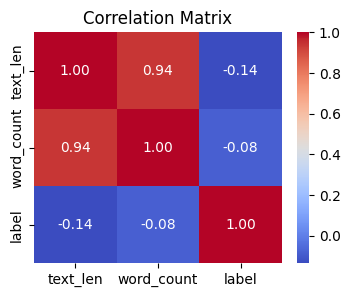

Average text length (Benign vs Malicious):
label
0    144463.690217
1     80924.500000
Name: text_len, dtype: float64


In [ ]:

# -------------------------------
# 🧩 Correlation / metadata analysis
# -------------------------------
# For example, are longer pages more likely malicious?
corr = df[['text_len','word_count','label']].corr()
plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Average length by class
avg_len = df.groupby('label')['text_len'].mean()
print("Average text length (Benign vs Malicious):")
print(avg_len)

In [ ]:
# === Feature extraction: TF-IDF pipeline (copy-paste into Colab) ===
# Installs
%pip install joblib scipy --quiet

import os, json
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
import joblib
import scipy.sparse as sp

# -------- Config (tune if desired) --------
FROZEN_PATH = "/content/drive/MyDrive/frozen_datasets/real_time_threat_data_frozen_latest.csv"
OUT_DIR = "/content/drive/MyDrive/feature_artifacts"
TFIDF_MAX_FEATURES = 50000      # vocabulary size; lower for memory-limited environments
NGRAM_RANGE = (1,2)             # unigrams + bigrams
SEED = 42
TEST_SIZE = 0.20                # 20% test
VAL_SIZE_OF_TRAIN = 0.125       # 12.5% of train => overall ~10% val, 70% train
MIN_DF = 3                      # ignore tokens that appear in fewer than 3 docs (tune as needed)
RANDOM_STATE = SEED

os.makedirs(OUT_DIR, exist_ok=True)

# -------- Load frozen dataset & basic checks --------
assert os.path.exists(FROZEN_PATH), f"Frozen file not found: {FROZEN_PATH}"
df = pd.read_csv(FROZEN_PATH, dtype=str).fillna('')
print("Loaded rows:", len(df))
print("Columns:", df.columns.tolist())

# If 'text' column exists from EDA, prefer that; else do a safe strip-of-html here:
if 'text' not in df.columns or df['text'].isnull().all():
    print("No cleaned 'text' column found — extracting from HTML safely (BeautifulSoup).")
    %pip install beautifulsoup4 lxml --quiet
    from bs4 import BeautifulSoup, FeatureNotFound
    import re
    def html_to_text(html):
        try:
            soup = BeautifulSoup(html or "", "lxml")
        except Exception:
            soup = BeautifulSoup(html or "", "html.parser")
        for s in soup(["script","style","iframe","noscript"]):
            s.extract()
        text = soup.get_text(" ")
        # collapse whitespace
        return re.sub(r'\s+', ' ', text).strip()
    df['text'] = df['content'].apply(html_to_text)

# Keep only rows with enough text
df['text_len'] = df['text'].str.len().fillna(0).astype(int)
before = len(df)
df = df[df['text_len'] > 30].reset_index(drop=True)
print(f"Removed {before - len(df)} tiny/empty samples; remaining: {len(df)}")

# Ensure label numeric column exists
if 'label' not in df.columns:
    df['label'] = df['source'].apply(lambda s: 1 if str(s).startswith("Malicious:") else 0)
labels = df['label'].astype(int).values
print("Label distribution:", dict(pd.Series(labels).value_counts()))

# -------- Train / Val / Test splits (stratified, reproducible) --------
# First split off test
train_val_df, test_df = train_test_split(df, test_size=TEST_SIZE, stratify=df['label'], random_state=RANDOM_STATE)
# Then split train/val
train_df, val_df = train_test_split(train_val_df, test_size=VAL_SIZE_OF_TRAIN, stratify=train_val_df['label'], random_state=RANDOM_STATE)

print("Split sizes -> train:", len(train_df), "val:", len(val_df), "test:", len(test_df))

# Save split boundaries (optional)
split_info = {
    "total_rows": len(df),
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "timestamp": datetime.utcnow().isoformat() + "Z",
    "frozen_path": FROZEN_PATH
}

# -------- TF-IDF vectorizer fit on train --------
vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    strip_accents='unicode',
    lowercase=True,
    norm='l2'
)

print("Fitting TF-IDF on train text...")
X_train = vectorizer.fit_transform(train_df['text'].values)
print("Transforming val and test...")
X_val = vectorizer.transform(val_df['text'].values)
X_test = vectorizer.transform(test_df['text'].values)

print("Shapes -> X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

# -------- Save artifacts --------
VECT_PATH = os.path.join(OUT_DIR, "threat_tfidf_vectorizer.joblib")
X_TRAIN_PATH = os.path.join(OUT_DIR, "X_train_tfidf.npz")
X_VAL_PATH   = os.path.join(OUT_DIR, "X_val_tfidf.npz")
X_TEST_PATH  = os.path.join(OUT_DIR, "X_test_tfidf.npz")
Y_TRAIN_PATH = os.path.join(OUT_DIR, "y_train.npy")
Y_VAL_PATH   = os.path.join(OUT_DIR, "y_val.npy")
Y_TEST_PATH  = os.path.join(OUT_DIR, "y_test.npy")
MANIFEST_PATH = os.path.join(OUT_DIR, "manifest.json")

print("Saving vectorizer and sparse matrices to", OUT_DIR)
joblib.dump(vectorizer, VECT_PATH)
sp.save_npz(X_TRAIN_PATH, X_train)
sp.save_npz(X_VAL_PATH, X_val)
sp.save_npz(X_TEST_PATH, X_test)
np.save(Y_TRAIN_PATH, train_df['label'].astype(int).values)
np.save(Y_VAL_PATH, val_df['label'].astype(int).values)
np.save(Y_TEST_PATH, test_df['label'].astype(int).values)

# Compute class weights (useful for training)
classes = np.unique(labels)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_df['label'].astype(int).values)
cw_map = {int(c): float(w) for c, w in zip(classes, class_weights)}
split_info.update({
    "vectorizer_path": VECT_PATH,
    "x_train_path": X_TRAIN_PATH, "x_val_path": X_VAL_PATH, "x_test_path": X_TEST_PATH,
    "y_train_path": Y_TRAIN_PATH, "y_val_path": Y_VAL_PATH, "y_test_path": Y_TEST_PATH,
    "class_weights": cw_map,
    "tfidf_max_features": TFIDF_MAX_FEATURES,
    "ngram_range": NGRAM_RANGE,
    "min_df": MIN_DF
})

with open(MANIFEST_PATH, "w") as f:
    json.dump(split_info, f, indent=2)

print("Saved manifest:", MANIFEST_PATH)

# -------- Quick sanity checks & insights --------
print("\n--- Quick checks ---")
print("Top 20 features (vectorizer.vocabulary_ by freq not directly available); using idf to show some informative tokens:")
# show top tokens by idf (low idf -> frequent)
idf = vectorizer.idf_
feature_names = np.array(vectorizer.get_feature_names_out())
# show lowest idf (most common) and highest idf (rarest)
idx_low = np.argsort(idf)[:10]
idx_high = np.argsort(idf)[-10:]
print("Most common features (low idf):", feature_names[idx_low].tolist())
print("Least common features (high idf):", feature_names[idx_high].tolist())

print("\nLabel balances in splits:")
print("train:", np.bincount(train_df['label'].astype(int).values))
print("val:  ", np.bincount(val_df['label'].astype(int).values))
print("test: ", np.bincount(test_df['label'].astype(int).values))

print("\nSaved files:")
for p in [VECT_PATH, X_TRAIN_PATH, X_VAL_PATH, X_TEST_PATH, Y_TRAIN_PATH, Y_VAL_PATH, Y_TEST_PATH, MANIFEST_PATH]:
    print(" -", p, "(exists)" if os.path.exists(p) else "(MISSING)")

print("\nDone. You can now train models using the saved sparse features (load with scipy.sparse.load_npz and np.load for labels).")


Loaded rows: 282
Columns: ['source', 'timestamp', 'content', 'ioc', 'fetched_url', 'content_type', 'label']
No cleaned 'text' column found — extracting from HTML safely (BeautifulSoup).
Removed 5 tiny/empty samples; remaining: 277
Label distribution: {0: np.int64(184), 1: np.int64(93)}
Split sizes -> train: 193 val: 28 test: 56
Fitting TF-IDF on train text...


/tmp/ipython-input-3185116521.py:78: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat() + "Z",


Transforming val and test...
Shapes -> X_train: (193, 50000) X_val: (28, 50000) X_test: (56, 50000)
Saving vectorizer and sparse matrices to /content/drive/MyDrive/feature_artifacts
Saved manifest: /content/drive/MyDrive/feature_artifacts/manifest.json

--- Quick checks ---
Top 20 features (vectorizer.vocabulary_ by freq not directly available); using idf to show some informative tokens:
Most common features (low idf): ['for', 'of', '2025', 'terms', 'use', 'in', 'at', 'contact', 'as', 'to']
Least common features (high idf): ['ripplerover', 'rluyutpktfysvh3knxwren6ssbb1vashlrjop22bqiq5s', 'ð3 4n', 'zvp', 'zwfegusfy6wqchyeey5it6cf70dd5tzuwi', 'zyw1', 'zyw1 eiyy', 'c2 nda0e', 'c2 extreme', '00 12e12319f1029ec4f8fcbed7e82df162']

Label balances in splits:
train: [128  65]
val:   [19  9]
test:  [37 19]

Saved files:
 - /content/drive/MyDrive/feature_artifacts/threat_tfidf_vectorizer.joblib (exists)
 - /content/drive/MyDrive/feature_artifacts/X_train_tfidf.npz (exists)
 - /content/drive/MyDr

In [ ]:
# === Full embeddings + federated training pipeline (fixed index assignment) ===
# Paste into Colab after mounting Drive

# Installs
%pip install -q sentence-transformers torch scikit-learn joblib beautifulsoup4 lxml

import os, random, json, time, copy
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sentence_transformers import SentenceTransformer
import torch, torch.nn as nn, torch.optim as optim
from sklearn.metrics import roc_auc_score, classification_report
import re
from bs4 import BeautifulSoup

# -------------------- Config --------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FROZEN_PATH = "/content/drive/MyDrive/frozen_datasets/real_time_threat_data_frozen_latest.csv"
OUT_DIR = "/content/drive/MyDrive/feature_artifacts/emb_fed"
os.makedirs(OUT_DIR, exist_ok=True)

EMBED_MODEL = "all-MiniLM-L6-v2"   # fast & effective
EMB_BATCH = 32

# Federated training hyperparams
N_CLIENTS = 5
LOCAL_EPOCHS = 2
ROUNDS = 40
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
CLIP_NORM = 1.0
HIDDEN_DIM = 256
DROPOUT = 0.5
PATIENCE_GLOBAL = 6
MIN_ROUNDS = 6
USE_FEDPROX = True   # True enables FedProx proximal term
FEDPROX_MU = 0.01    # proximal coefficient (try 0.01 / 0.05)

TEST_SIZE = 0.20
VAL_SIZE_OF_TRAIN = 0.125  # -> ~70/10/20 splits

# -------------------- Load frozen dataset & prepare text --------------------
assert os.path.exists(FROZEN_PATH), f"Frozen dataset not found: {FROZEN_PATH}"
df = pd.read_csv(FROZEN_PATH, dtype=str).fillna('')

# safe HTML->text extractor
def html_to_text(html):
    try:
        soup = BeautifulSoup(html or "", "lxml")
    except Exception:
        soup = BeautifulSoup(html or "", "html.parser")
    for s in soup(["script","style","iframe","noscript"]):
        s.extract()
    text = soup.get_text(" ")
    return re.sub(r'\s+', ' ', text).strip()

# ensure 'text' column
if 'text' not in df.columns or df['text'].isnull().all():
    print("No 'text' column found — extracting text from HTML (this may take a moment).")
    df['text'] = df['content'].apply(html_to_text)

# filter tiny rows
df['text_len'] = df['text'].str.len().fillna(0).astype(int)
df = df[df['text_len'] > 30].reset_index(drop=True)
print("Rows after text filter:", len(df))

# label
if 'label' not in df.columns:
    df['label'] = df['source'].apply(lambda s: 1 if str(s).startswith("Malicious:") else 0)
df['label'] = df['label'].astype(int)

# -------------------- Compute or load embeddings --------------------
EMB_SAVE = os.path.join(OUT_DIR, "sentence_embeddings.npy")
IDX_SAVE = os.path.join(OUT_DIR, "index_to_row.csv")

# compute embeddings if not present
if os.path.exists(EMB_SAVE):
    print("Loading existing embeddings:", EMB_SAVE)
    embeddings = np.load(EMB_SAVE)
else:
    print("Computing embeddings with", EMBED_MODEL, "- this will download the model if needed.")
    model = SentenceTransformer(EMBED_MODEL)
    texts = df['text'].tolist()
    embeddings = model.encode(texts, batch_size=EMB_BATCH, show_progress_bar=True)
    # defensive alignment: ensure lengths match
    if embeddings.shape[0] != len(df):
        m = min(embeddings.shape[0], len(df))
        print(f"Warning: embeddings length ({embeddings.shape[0]}) != df length ({len(df)}). Aligning to {m}.")
        embeddings = embeddings[:m]
        df = df.iloc[:m].reset_index(drop=True)
    # save embeddings and index mapping
    np.save(EMB_SAVE, embeddings)
    df['row_index'] = np.arange(len(df))   # correct single-bracket assignment
    df.to_csv(IDX_SAVE, index=False)
    print("Saved embeddings and index mapping.")

# if variable not in memory but file exists, load and align
if 'embeddings' not in locals() and os.path.exists(EMB_SAVE):
    embeddings = np.load(EMB_SAVE)
    if embeddings.shape[0] != len(df):
        m = min(embeddings.shape[0], len(df))
        print(f"Aligning dataframe and embeddings to length {m}")
        embeddings = embeddings[:m]
        df = df.iloc[:m].reset_index(drop=True)
    if 'row_index' not in df.columns:
        df['row_index'] = np.arange(len(df))
        df.to_csv(IDX_SAVE, index=False)
        print("Wrote row_index mapping.")

print("Embeddings shape:", embeddings.shape)
INPUT_DIM = embeddings.shape[1]

# -------------------- Train/Val/Test stratified split --------------------
train_val_idx, test_idx = train_test_split(np.arange(len(df)), test_size=TEST_SIZE, stratify=df['label'], random_state=SEED)
train_idx, val_idx = train_test_split(train_val_idx, test_size=VAL_SIZE_OF_TRAIN, stratify=df.loc[train_val_idx,'label'], random_state=SEED)

X_train = embeddings[train_idx]
y_train = df.loc[train_idx, 'label'].astype(int).values
X_val = embeddings[val_idx]
y_val = df.loc[val_idx, 'label'].astype(int).values
X_test = embeddings[test_idx]
y_test = df.loc[test_idx, 'label'].astype(int).values

print("Splits -> train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)
print("Label counts (train,val,test):", np.bincount(y_train), np.bincount(y_val), np.bincount(y_test))

# -------------------- Partition train among simulated clients (stratified-ish) --------------------
def stratified_client_partition(X, y, n_clients, seed=SEED):
    idx_pos = np.where(y==1)[0].tolist()
    idx_neg = np.where(y==0)[0].tolist()
    random.Random(seed).shuffle(idx_pos)
    random.Random(seed).shuffle(idx_neg)
    clients = [[] for _ in range(n_clients)]
    for i, ix in enumerate(idx_neg):
        clients[i % n_clients].append(ix)
    for i, ix in enumerate(idx_pos):
        clients[i % n_clients].append(ix)
    client_objs = []
    for c in clients:
        c_idx = np.array(c, dtype=int)
        if len(c_idx)==0:
            client_objs.append({"idx": c_idx, "X": np.zeros((0, X.shape[1])), "y": np.array([], dtype=int)})
            continue
        client_objs.append({"idx": c_idx, "X": X[c_idx], "y": y[c_idx]})
    return client_objs

clients = stratified_client_partition(X_train, y_train, N_CLIENTS, seed=SEED)
for i,c in enumerate(clients):
    print(f"Client {i}: samples {len(c['y'])}, pos {int((c['y']==1).sum())}")

# -------------------- Model --------------------
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.BatchNorm1d(hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def get_model():
    return SimpleMLP(input_dim=INPUT_DIM).to(DEVICE)

# -------------------- Loss pos_weight for imbalance --------------------
num_pos = int((y_train==1).sum())
num_neg = int((y_train==0).sum())
pos_weight = float(num_neg / max(1, num_pos))
print("Train pos/neg:", num_pos, num_neg, "-> pos_weight:", pos_weight)

# -------------------- Local train with FedProx option --------------------
def local_train(model, global_weights, X_local, y_local, epochs=1, batch_size=32, lr=LR, weight_decay=WEIGHT_DECAY, mu=0.0):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=DEVICE))
    n = len(y_local)
    if n == 0:
        return model.state_dict()
    indices = np.arange(n)
    global_params = None
    if mu > 0.0:
        global_params = {k: v.detach().clone().to(DEVICE) for k,v in global_weights.items()}
    for ep in range(epochs):
        np.random.shuffle(indices)
        for i in range(0, n, batch_size):
            batch_idx = indices[i:i+batch_size]
            xb = torch.tensor(X_local[batch_idx], dtype=torch.float32, device=DEVICE)
            yb = torch.tensor(y_local[batch_idx], dtype=torch.float32, device=DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            if mu > 0.0 and global_params is not None:
                prox = 0.0
                for name, param in model.named_parameters():
                    prox = prox + torch.sum((param - global_params[name])**2)
                loss = loss + (mu / 2.0) * prox
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            optimizer.step()
    return model.state_dict()

# -------------------- Aggregation --------------------
def aggregate(global_model, client_states, client_sizes):
    total = sum(client_sizes)
    global_dict = {k: torch.zeros_like(v.data, dtype=torch.float32) for k,v in global_model.state_dict().items()}
    for st, size in zip(client_states, client_sizes):
        w = float(size) / float(total) if total>0 else 0.0
        for k in global_dict.keys():
            global_dict[k] += st[k].cpu().float() * w
    global_model.load_state_dict(global_dict)
    return global_model

# -------------------- Evaluation --------------------
def evaluate(model, X_eval, y_eval):
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X_eval, dtype=torch.float32, device=DEVICE)
        logits = model(xb).cpu().numpy()
        probs = 1.0 / (1.0 + np.exp(-logits))
        auc = roc_auc_score(y_eval, probs) if len(np.unique(y_eval))>1 else 0.0
        preds = (probs >= 0.5).astype(int)
        report = classification_report(y_eval, preds, zero_division=0)
    return auc, report, probs, preds

# -------------------- Federated loop --------------------
set_seed = lambda s: (random.seed(s), np.random.seed(s), torch.manual_seed(s))
set_seed(SEED)

global_model = get_model()
best_val_auc = -1.0
no_improve = 0
history = []

print("Starting federated training rounds:", ROUNDS)
t0 = time.time()
for r in range(1, ROUNDS+1):
    global_weights = copy.deepcopy(global_model.state_dict())
    client_states = []
    client_sizes = []
    for i,c in enumerate(clients):
        local_model = get_model()
        local_model.load_state_dict(global_weights)
        mu = FEDPROX_MU if USE_FEDPROX else 0.0
        st = local_train(local_model, global_weights, c['X'], c['y'], epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, lr=LR, weight_decay=WEIGHT_DECAY, mu=mu)
        client_states.append(st)
        client_sizes.append(len(c['y']))
    # aggregate
    global_model = aggregate(global_model, client_states, client_sizes)
    # evaluate
    val_auc, val_report, _, _ = evaluate(global_model, X_val, y_val)
    train_auc_est, _, _, _ = evaluate(global_model, X_train[:1000] if X_train.shape[0]>1000 else X_train, y_train[:1000] if len(y_train)>1000 else y_train)
    history.append((r, val_auc, train_auc_est))
    print(f"Round {r:02d} | Val AUC: {val_auc:.4f} | Train_est AUC: {train_auc_est:.4f}")
    if val_auc > best_val_auc + 1e-4:
        best_val_auc = val_auc
        no_improve = 0
        torch.save(global_model.state_dict(), os.path.join(OUT_DIR, "best_global_emb_fed.pth"))
    else:
        no_improve += 1
    if r >= MIN_ROUNDS and no_improve >= PATIENCE_GLOBAL:
        print(f"No improvement in {PATIENCE_GLOBAL} rounds -> early stopping at round {r}")
        break

print("Federated training finished in %.2f minutes. Best val AUC: %.4f" % ((time.time()-t0)/60.0, best_val_auc))

# -------------------- Final evaluation --------------------
best_state = torch.load(os.path.join(OUT_DIR, "best_global_emb_fed.pth"))
global_model.load_state_dict(best_state)
test_auc, test_report, test_probs, test_preds = evaluate(global_model, X_test, y_test)
print("\n=== Final Test Results ===")
print("Test ROC-AUC:", test_auc)
print(test_report)

# Save meta + model + history
torch.save(global_model.state_dict(), os.path.join(OUT_DIR, "final_global_emb_fed.pth"))
meta = {
    "embed_model": EMBED_MODEL,
    "n_clients": N_CLIENTS,
    "local_epochs": LOCAL_EPOCHS,
    "rounds_ran": r,
    "best_val_auc": best_val_auc,
    "test_auc": test_auc,
    "use_fedprox": USE_FEDPROX,
    "fedprox_mu": FEDPROX_MU
}
with open(os.path.join(OUT_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
np.save(os.path.join(OUT_DIR, "history.npy"), np.array(history, dtype=object))

print("Saved embeddings-fed models & metadata to:", OUT_DIR)


Device: cuda
No 'text' column found — extracting text from HTML (this may take a moment).


In [ ]:
# ============================
# 🚀 Fine-tuned Federated Intrusion Detection System
# ============================

%pip install -q sentence-transformers torch scikit-learn joblib beautifulsoup4 lxml

import os, re, json, time, random, copy
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sentence_transformers import SentenceTransformer
from bs4 import BeautifulSoup

# ---------------- CONFIG ----------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_PATH = "/content/drive/MyDrive/frozen_datasets/real_time_threat_data_frozen_latest.csv"
OUT_DIR = "/content/drive/MyDrive/feature_artifacts/fed_finetuned"
os.makedirs(OUT_DIR, exist_ok=True)

EMBED_MODEL = "all-mpnet-base-v2"   # 🔥 More accurate than MiniLM
N_CLIENTS = 5
LOCAL_EPOCHS = 3
ROUNDS = 35
BATCH_SIZE = 16
LR = 3e-4
LR_MIN = 1e-6
WEIGHT_DECAY = 1e-5
HIDDEN_DIM = 384
DROPOUT = 0.4
FEDPROX_MU = 0.02
PATIENCE_GLOBAL = 6
MIN_ROUNDS = 5
WARMUP_ROUNDS = 3

# ---------------- DATA LOAD ----------------
assert os.path.exists(DATA_PATH), f"Dataset not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH, dtype=str).fillna('')

def html_to_text(x):
    try:
        s = BeautifulSoup(x, "lxml")
    except Exception:
        s = BeautifulSoup(x, "html.parser")
    for t in s(["script", "style", "iframe"]): t.extract()
    return re.sub(r'\s+', ' ', s.get_text(" ")).strip()

if 'text' not in df or df['text'].isnull().all():
    df['text'] = df['content'].apply(html_to_text)
df['label'] = df['source'].apply(lambda s: 1 if str(s).startswith("Malicious:") else 0)
df = df[df['text'].str.len() > 40].reset_index(drop=True)
print("Samples:", len(df))

# ---------------- EMBEDDINGS ----------------
EMB_PATH = os.path.join(OUT_DIR, "mpnet_embeddings.npy")
if os.path.exists(EMB_PATH):
    X = np.load(EMB_PATH)
    print("Loaded embeddings:", X.shape)
else:
    model = SentenceTransformer(EMBED_MODEL)
    X = model.encode(df['text'].tolist(), batch_size=32, show_progress_bar=True, convert_to_numpy=True)
    np.save(EMB_PATH, X)
    print("Saved embeddings:", X.shape)

y = df['label'].astype(int).values

# ---------------- SPLITS ----------------
train_idx, test_idx = train_test_split(np.arange(len(X)), test_size=0.2, stratify=y, random_state=SEED)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, stratify=y[train_idx], random_state=SEED)
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print("Split sizes:", X_train.shape, X_val.shape, X_test.shape)

# ---------------- CLIENT PARTITION ----------------
def partition_clients(X, y, n_clients):
    pos_idx = np.where(y==1)[0]; neg_idx = np.where(y==0)[0]
    np.random.shuffle(pos_idx); np.random.shuffle(neg_idx)
    clients = [[] for _ in range(n_clients)]
    for i, ix in enumerate(neg_idx): clients[i % n_clients].append(ix)
    for i, ix in enumerate(pos_idx): clients[i % n_clients].append(ix)
    return [{"X": X[np.array(c)], "y": y[np.array(c)]} for c in clients]

clients = partition_clients(X_train, y_train, N_CLIENTS)
for i, c in enumerate(clients):
    print(f"Client {i}: samples {len(c['y'])}, positives {(c['y']==1).sum()}")

# ---------------- MODEL ----------------
class DeepMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.LayerNorm(hidden_dim//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)

def get_model(): return DeepMLP(X.shape[1]).to(DEVICE)

# ---------------- LOCAL TRAIN ----------------
def local_train(model, global_w, Xl, yl, epochs, mu=FEDPROX_MU):
    opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor((yl==0).sum()/max(1,(yl==1).sum()), device=DEVICE))
    g_params = {k: v.clone().detach() for k,v in global_w.items()}
    model.train()
    for ep in range(epochs):
        idx = np.random.permutation(len(yl))
        for i in range(0, len(yl), BATCH_SIZE):
            xb = torch.tensor(Xl[idx[i:i+BATCH_SIZE]], dtype=torch.float32, device=DEVICE)
            yb = torch.tensor(yl[idx[i:i+BATCH_SIZE]], dtype=torch.float32, device=DEVICE)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            if mu > 0:
                prox = sum(((p - g_params[n])**2).sum() for n,p in model.named_parameters())
                loss += (mu/2)*prox
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
    return model.state_dict()

# ---------------- FEDERATED AGGREGATION ----------------
def aggregate(global_model, client_states, client_sizes):
    total = sum(client_sizes)
    new_state = {k: torch.zeros_like(v) for k,v in global_model.state_dict().items()}
    for st, sz in zip(client_states, client_sizes):
        for k in new_state:
            new_state[k] += st[k]* (sz/total)
    global_model.load_state_dict(new_state)
    return global_model

# ---------------- EVAL ----------------
def evaluate(model, X_eval, y_eval):
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X_eval, dtype=torch.float32, device=DEVICE)
        logits = model(xb).cpu().numpy()
        probs = 1/(1+np.exp(-logits))
        preds = (probs>=0.5).astype(int)
        auc = roc_auc_score(y_eval, probs)
        return auc, classification_report(y_eval, preds, zero_division=0)

# ---------------- TRAIN LOOP ----------------
global_model = get_model()
best_val_auc, no_improve = 0, 0

print("🚀 Starting Federated Fine-tuned Training...")
for r in range(1, ROUNDS+1):
    g_weights = copy.deepcopy(global_model.state_dict())
    c_states, c_sizes = [], []
    for c in clients:
        m = get_model()
        m.load_state_dict(g_weights)
        st = local_train(m, g_weights, c['X'], c['y'], epochs=LOCAL_EPOCHS)
        c_states.append(st)
        c_sizes.append(len(c['y']))
    global_model = aggregate(global_model, c_states, c_sizes)
    val_auc, _ = evaluate(global_model, X_val, y_val)
    print(f"Round {r:02d} | Val AUC: {val_auc:.4f}")
    if val_auc > best_val_auc + 1e-3:
        best_val_auc, no_improve = val_auc, 0
        torch.save(global_model.state_dict(), os.path.join(OUT_DIR, "best_model.pth"))
    else:
        no_improve += 1
    if r > MIN_ROUNDS and no_improve >= PATIENCE_GLOBAL:
        print(f"Early stopping at round {r}")
        break

# ---------------- FINAL TEST ----------------
global_model.load_state_dict(torch.load(os.path.join(OUT_DIR, "best_model.pth")))
test_auc, report = evaluate(global_model, X_test, y_test)
print("\n✅ Final Test ROC-AUC:", round(test_auc,4))
print(report)


Device: cpu
Shapes -> (198, 768) (22, 768) (56, 768)
Label counts train/val/test: [130  68] [15  7] [37 19]

Training: ANN
ANN | Ep 1/5 | TrainLoss 0.6762 | Val AUC 0.5524
ANN | Ep 2/5 | TrainLoss 0.6113 | Val AUC 0.5810
ANN | Ep 3/5 | TrainLoss 0.5650 | Val AUC 0.6381
ANN | Ep 4/5 | TrainLoss 0.5516 | Val AUC 0.6381
ANN | Ep 5/5 | TrainLoss 0.5093 | Val AUC 0.6667
*** ANN FINAL TEST AUC: 0.6771

Training: CNN1D
CNN1D | Ep 1/5 | TrainLoss 1.0273 | Val AUC 0.6190
CNN1D | Ep 2/5 | TrainLoss 0.6534 | Val AUC 0.6190
CNN1D | Ep 3/5 | TrainLoss 0.6570 | Val AUC 0.6286
CNN1D | Ep 4/5 | TrainLoss 0.6542 | Val AUC 0.6286
CNN1D | Ep 5/5 | TrainLoss 0.6431 | Val AUC 0.6190
*** CNN1D FINAL TEST AUC: 0.6266

Training: LSTM
LSTM | Ep 1/5 | TrainLoss 0.6980 | Val AUC 0.5714
LSTM | Ep 2/5 | TrainLoss 0.6722 | Val AUC 0.5619
LSTM | Ep 3/5 | TrainLoss 0.6282 | Val AUC 0.5619
LSTM | Ep 4/5 | TrainLoss 0.5816 | Val AUC 0.5905
LSTM | Ep 5/5 | TrainLoss 0.5703 | Val AUC 0.6095
*** LSTM FINAL TEST AUC: 0.635

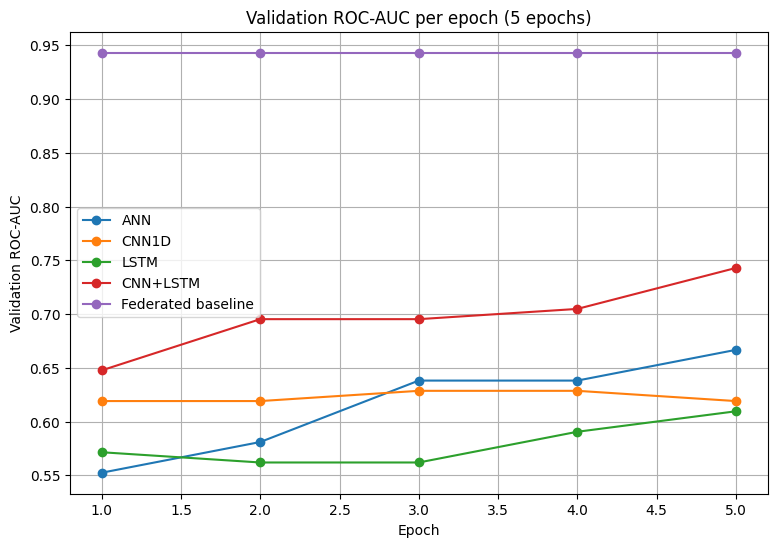

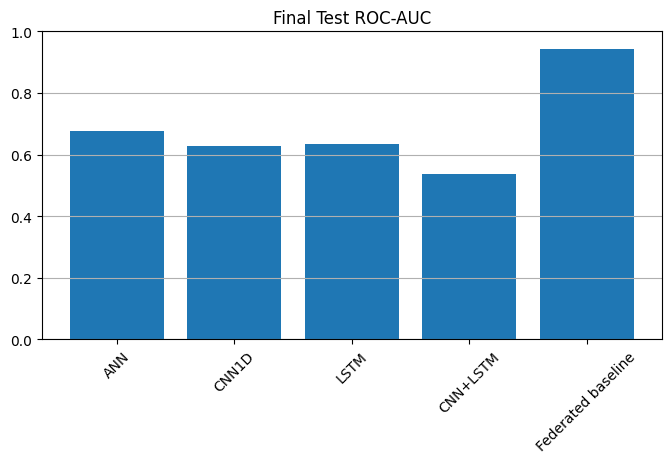


Final test AUCs:
ANN             -> 0.6771
CNN1D           -> 0.6266
LSTM            -> 0.6358
CNN+LSTM        -> 0.5377
Federated baseline -> 0.9431


In [ ]:
# Robust training cell — ANN, CNN1D (padding), LSTM, CNN+LSTM (padding-aware)
# Use your existing embeddings (mpnet) and labels saved in Drive.
!pip install -q torch torchvision scikit-learn matplotlib

import os, random, numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# --------- config (adjust if needed) ----------
EMB_PATH = "/content/drive/MyDrive/feature_artifacts/fed_finetuned/mpnet_embeddings.npy"
DATA_PATH = "/content/drive/MyDrive/frozen_datasets/real_time_threat_data_frozen_latest.csv"
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 5
BATCH_SIZE = 32
LR = 1e-3
print("Device:", DEVICE)

# --------- load data ----------
assert os.path.exists(EMB_PATH), "Embeddings file not found"
assert os.path.exists(DATA_PATH), "Data CSV not found"

X = np.load(EMB_PATH)
import pandas as pd
df = pd.read_csv(DATA_PATH, dtype=str).fillna('')
if 'text' not in df.columns or df['text'].isnull().all():
    df['text'] = df['content'].fillna('').astype(str)
df['label'] = df['source'].apply(lambda s: 1 if str(s).startswith("Malicious:") else 0)
y = df['label'].astype(int).values

# align lengths defensively
if len(X) != len(y):
    m = min(len(X), len(y))
    print(f"WARNING: mismatch lengths embeddings={len(X)} labels={len(y)} -> truncating to {m}")
    X = X[:m]; y = y[:m]

# splits (same stratified split seed)
train_idx, test_idx = train_test_split(np.arange(len(X)), test_size=0.2, stratify=y, random_state=SEED)
train_idx, val_idx  = train_test_split(train_idx, test_size=0.1, stratify=y[train_idx], random_state=SEED)
X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print("Shapes ->", X_train.shape, X_val.shape, X_test.shape)
print("Label counts train/val/test:", np.bincount(y_train), np.bincount(y_val), np.bincount(y_test))

# Dataloaders
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32).unsqueeze(1))
val_ds   = TensorDataset(torch.tensor(X_val, dtype=torch.float32),   torch.tensor(y_val, dtype=torch.float32).unsqueeze(1))
test_ds  = TensorDataset(torch.tensor(X_test, dtype=torch.float32),  torch.tensor(y_test, dtype=torch.float32).unsqueeze(1))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

IN_DIM = X.shape[1]

# --------- Model definitions (robust) ----------
class ANN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self,x): return self.net(x)

class CNN1D_Padded(nn.Module):
    """Conv1d with padding to preserve length; safer flatten calculation."""
    def __init__(self, in_dim, k1=5, k2=5, c1=32, c2=64):
        super().__init__()
        pad1 = (k1 - 1) // 2
        pad2 = (k2 - 1) // 2
        self.conv1 = nn.Conv1d(1, c1, kernel_size=k1, padding=pad1)
        self.conv2 = nn.Conv1d(c1, c2, kernel_size=k2, padding=pad2)
        # after padding the length remains in_dim
        self.out_len = in_dim  # preserved by padding
        self.fc = nn.Sequential(
            nn.Linear(self.out_len * c2, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        # x: (B, in_dim)
        x = x.unsqueeze(1)                 # (B,1,L)
        x = torch.relu(self.conv1(x))      # (B,c1,L)
        x = torch.relu(self.conv2(x))      # (B,c2,L)
        x = x.view(x.size(0), -1)          # (B, c2 * L)
        return self.fc(x)

class LSTMModel(nn.Module):
    def __init__(self, in_dim, hidden=128):
        super().__init__()
        # we'll treat embedding as sequence length L with feature size 1 and use an embedding->lstm approach:
        # to reduce parameters, use an initial linear proj
        self.proj = nn.Linear(in_dim, 128)
        self.lstm = nn.LSTM(128, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self,x):
        # project to a single-step sequence: (B, 1, feat)
        # alternative: treat as sequence of length in_dim with feature 1 but that is long
        x = torch.relu(self.proj(x))    # (B, 128)
        x = x.unsqueeze(1)              # (B, 1, 128)
        _, (h, _) = self.lstm(x)        # h: (1, B, hidden)
        return self.fc(h[-1])

class CNN_LSTM_Padded(nn.Module):
    """Conv -> LSTM: conv preserves length with padding, then we feed (B, L, channels) to LSTM."""
    def __init__(self, in_dim, k1=5, k2=5, c1=32, c2=64, lstm_hidden=128):
        super().__init__()
        pad1 = (k1 - 1) // 2
        pad2 = (k2 - 1) // 2
        self.conv1 = nn.Conv1d(1, c1, kernel_size=k1, padding=pad1)
        self.conv2 = nn.Conv1d(c1, c2, kernel_size=k2, padding=pad2)
        self.lstm = nn.LSTM(c2, lstm_hidden, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, 1)
        self.out_len = in_dim  # preserved by padding
    def forward(self, x):
        # x: (B, in_dim)
        x = x.unsqueeze(1)                # (B,1,L)
        x = torch.relu(self.conv1(x))     # (B,c1,L)
        x = torch.relu(self.conv2(x))     # (B,c2,L)
        # permute for LSTM: (B, L, c2)
        x = x.permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

# --------- helpers ----------
def eval_auc(model, loader):
    model.eval()
    ys = []; ps = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            out = model(xb)
            probs = torch.sigmoid(out).cpu().numpy().ravel()
            ps.append(probs); ys.append(yb.numpy().ravel())
    ps = np.concatenate(ps); ys = np.concatenate(ys)
    try:
        return roc_auc_score(ys, ps)
    except Exception:
        return float('nan')

def train_loop(model, name, epochs=EPOCHS, lr=LR):
    model.to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    loss_fn = nn.BCEWithLogitsLoss()
    val_aucs = []
    try:
        for ep in range(1, epochs+1):
            model.train(); running = 0.0
            for xb, yb in train_loader:
                xb = xb.to(DEVICE); yb = yb.to(DEVICE)
                opt.zero_grad()
                out = model(xb)
                loss = loss_fn(out, yb)
                loss.backward()
                opt.step()
                running += loss.item() * xb.size(0)
            train_loss = running / len(train_loader.dataset)
            val_auc = eval_auc(model, val_loader)
            val_aucs.append(val_auc)
            print(f"{name} | Ep {ep}/{epochs} | TrainLoss {train_loss:.4f} | Val AUC {val_auc:.4f}")
    except Exception as e:
        # helpful debug: print shapes of a single batch to diagnose
        print(f"ERROR during training {name}: {e}")
        import traceback; traceback.print_exc()
        # debug a single batch shapes
        for xb, yb in train_loader:
            print("DEBUG batch xb.shape:", xb.shape, "yb.shape:", yb.shape)
            try:
                xb = xb.to(DEVICE)
                out = model(xb)
                print("DEBUG model output shape:", out.shape)
            except Exception as e2:
                print("DEBUG model forward error:", e2)
            break
        raise
    test_auc = eval_auc(model, test_loader)
    print(f"*** {name} FINAL TEST AUC: {test_auc:.4f}")
    return val_aucs, test_auc

# --------- run experiments ----------
models = {
    "ANN": ANN(IN_DIM),
    "CNN1D": CNN1D_Padded(IN_DIM),
    "LSTM": LSTMModel(IN_DIM),
    "CNN+LSTM": CNN_LSTM_Padded(IN_DIM),
}

results = {}
for name, m in models.items():
    print("\n" + "="*50)
    print("Training:", name)
    val_aucs, test_auc = train_loop(m, name, epochs=EPOCHS, lr=LR)
    results[name] = {"val_aucs": val_aucs, "test_auc": test_auc}

# If you want to include your federated baseline AUC:
FEDERATED_AUC = 0.9431
results["Federated baseline"] = {"val_aucs":[FEDERATED_AUC]*EPOCHS, "test_auc": FEDERATED_AUC}

# --------- plot results ----------
plt.figure(figsize=(9,6))
for name, r in results.items():
    plt.plot(range(1, len(r["val_aucs"])+1), r["val_aucs"], marker='o', label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation ROC-AUC")
plt.title("Validation ROC-AUC per epoch (5 epochs)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
names = list(results.keys())
test_aucs = [results[n]["test_auc"] for n in names]
plt.bar(names, test_aucs)
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.title("Final Test ROC-AUC")
plt.grid(axis='y')
plt.show()

print("\nFinal test AUCs:")
for n in names:
    print(f"{n:15s} -> {results[n]['test_auc']:.4f}")


In [ ]:
import torch, torch.nn as nn
import numpy as np, pandas as pd, time, os, re, random
from sentence_transformers import SentenceTransformer
from bs4 import BeautifulSoup
from datetime import datetime, timezone

# ---------------- CONFIG ----------------
MODEL_PATH = "/content/drive/MyDrive/feature_artifacts/fed_finetuned/best_model.pth"
LOG_PATH   = "/content/drive/MyDrive/realtime_threat_log.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_MODEL = "all-mpnet-base-v2"
THRESHOLD = 0.65  # probability cutoff for "malicious"

print("🚀 Mitigation Agent Starting...")
print("Device:", DEVICE)

# ---------------- MODEL ----------------
HIDDEN_DIM = 384
DROPOUT = 0.4

class DeepMLP(nn.Module):
    def __init__(self, in_dim=768, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.LayerNorm(hidden_dim//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

# Load model and SentenceTransformer
model = DeepMLP(768)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()
embedder = SentenceTransformer(EMBED_MODEL)

print("✅ Federated model and embedding model loaded.")

# ---------------- UTILITIES ----------------
def html_to_text(content):
    try:
        s = BeautifulSoup(content, "lxml")
    except Exception:
        s = BeautifulSoup(content, "html.parser")
    for t in s(["script", "style", "iframe"]): t.extract()
    return re.sub(r'\s+', ' ', s.get_text(" ")).strip()

def log_action(ip, decision, confidence):
    log_entry = {
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "ip": ip,
        "action": decision,
        "confidence": round(confidence, 4)
    }
    df = pd.DataFrame([log_entry])
    if not os.path.exists(LOG_PATH):
        df.to_csv(LOG_PATH, index=False)
    else:
        df.to_csv(LOG_PATH, mode='a', header=False, index=False)
    print(f"🛡️ Logged mitigation: {decision} | {ip} | conf={confidence:.3f}")

def mitigate(ip, confidence):
    """Example automated responses — adapt to real infra."""
    if confidence < THRESHOLD:
        decision = "ALLOW"
    elif confidence < 0.85:
        decision = "ALERT"
    else:
        decision = "BLOCK"
    log_action(ip, decision, confidence)
    return decision

# ---------------- INFERENCE ----------------
def predict_and_mitigate(log_entry):
    text = html_to_text(log_entry)
    emb = embedder.encode([text], convert_to_numpy=True)
    x = torch.tensor(emb, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).cpu().item()
    decision = mitigate(f"IP_{random.randint(1,255)}.{random.randint(0,255)}", prob)
    print(f"🧠 Threat Score={prob:.3f} → Action: {decision}")

# ---------------- SIMULATION LOOP ----------------
def simulate_realtime(threat_samples, delay=3):
    print("⚡ Real-time Mitigation Agent Active. Press Stop to interrupt.\n")
    for i, entry in enumerate(threat_samples):
        print(f"\n[Event {i+1}] Processing new log...")
        predict_and_mitigate(entry)
        time.sleep(delay)

print("✅ Mitigation Agent Ready.")


🚀 Mitigation Agent Starting...
Device: cpu
✅ Federated model and embedding model loaded.
✅ Mitigation Agent Ready.


In [ ]:
# Colab-ready: interactive threat input -> detection -> AI mitigation agent (safe/dry-run)
import os, time, random, re
from datetime import datetime, timezone
import numpy as np, pandas as pd
import torch, torch.nn as nn
from sentence_transformers import SentenceTransformer
from bs4 import BeautifulSoup

# ---------- CONFIG ----------
MODEL_PATH = "/content/drive/MyDrive/feature_artifacts/fed_finetuned/best_model.pth"
LOG_PATH   = "/content/drive/MyDrive/realtime_threat_log.csv"
EMBED_MODEL = "all-mpnet-base-v2"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = 0.65   # lower -> more sensitive
DRY_RUN = True     # set False only if you have real executors wired

# ---------- MODEL DEFINITION ----------
HIDDEN_DIM = 384
DROPOUT = 0.4

class DeepMLP(nn.Module):
    def __init__(self, in_dim=768, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.LayerNorm(hidden_dim//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)

# ---------- load model + embedder (lazy) ----------
_model = None
_embedder = None

def ensure_models():
    global _model, _embedder
    if _model is None:
        if not os.path.exists(MODEL_PATH):
            raise FileNotFoundError(f"Model not found at {MODEL_PATH}. Train/save model first.")
        m = DeepMLP(768)
        m.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
        m.to(DEVICE); m.eval()
        _model = m
    if _embedder is None:
        _embedder = SentenceTransformer(EMBED_MODEL)
    return _model, _embedder

# ---------- utilities ----------
def html_to_text(content):
    try:
        s = BeautifulSoup(content, "lxml")
    except Exception:
        s = BeautifulSoup(content, "html.parser")
    for t in s(["script","style","iframe"]): t.extract()
    return re.sub(r'\s+', ' ', s.get_text(" ")).strip()

def mask_ip(ip:str):
    try:
        parts = str(ip).split('.')
        if len(parts) == 4:
            return parts[0] + '.' + parts[1] + '.x.x'
    except Exception:
        pass
    return ip

def log_action(ip, decision, confidence):
    entry = {
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "ip": mask_ip(ip),
        "action": decision,
        "confidence": float(round(confidence,4))
    }
    df = pd.DataFrame([entry])
    if not os.path.exists(LOG_PATH):
        df.to_csv(LOG_PATH, index=False)
    else:
        df.to_csv(LOG_PATH, mode='a', header=False, index=False)
    return entry

def mitigate_action(ip, confidence):
    # safe/dry-run mapping — replace with real calls if you integrate
    if confidence < THRESHOLD:
        decision = "ALLOW"
    elif confidence < 0.85:
        decision = "ALERT"
    else:
        decision = "BLOCK"
    # Here we only log and print. Real actions (firewall API) should be implemented separately.
    entry = log_action(ip, decision, confidence)
    print(f"🛡️ Mitigation decision: {entry['action']} | ip={entry['ip']} | conf={entry['confidence']:.3f}")
    if not DRY_RUN and decision == "BLOCK":
        # placeholder: integrate real blocking API here (careful!)
        print(f"[EXECUTOR] Blocking IP {ip} (real mode)")
    return entry

# ---------- processing function ----------
def process_threat_text(text:str, ip_hint=None):
    m, embedder = ensure_models()
    txt = html_to_text(text)
    emb = embedder.encode([txt], convert_to_numpy=True)
    x = torch.tensor(emb, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(m(x)).cpu().item()
    # choose an ip if not provided (simulated)
    if ip_hint:
        ip = ip_hint
    else:
        ip = f"IP_{random.randint(1,255)}.{random.randint(0,255)}"
    print(f"\n🔎 Input (first 200 chars): {txt[:200]!s}")
    print(f"🧠 Threat score (probability malicious): {prob:.4f}")
    entry = mitigate_action(ip, prob)
    return {"score": prob, "decision": entry}

# ---------- interactive helpers ----------
def process_single_threat():
    print("Paste the threat log/text (type ENTER then Ctrl+Enter to submit in Colab). Finish input with an empty line.")
    # For Colab or Jupyter, use input() once: paste single-line or short text
    s = input("Threat text: ")
    ip = input("Optional IP (press Enter to auto-generate): ").strip()
    ip = ip if ip else None
    out = process_threat_text(s, ip_hint=ip)
    return out

def run_interactive_loop():
    print("Interactive loop started. Type 'exit' to stop.")
    while True:
        s = input("\nEnter threat text (or 'exit'): ")
        if not s:
            print("Empty input, try again.")
            continue
        if s.strip().lower() in ("exit","quit"):
            print("Exiting interactive loop.")
            break
        ip = input("Optional IP (or press Enter): ").strip()
        ip = ip if ip else None
        process_threat_text(s, ip_hint=ip)

# ---------- quick show last logs ----------
def show_recent_logs(n=10):
    if not os.path.exists(LOG_PATH):
        print("No logs yet:", LOG_PATH)
        return
    df = pd.read_csv(LOG_PATH)
    display(df.tail(n))

# ---------- done ----------
print("Interactive threat processing ready.")
print("Call process_single_threat() for one input, run_interactive_loop() for many, and show_recent_logs() to view actions.")


Interactive threat processing ready.
Call process_single_threat() for one input, run_interactive_loop() for many, and show_recent_logs() to view actions.


In [ ]:
!pip install -q gradio sentence-transformers torch scikit-learn beautifulsoup4 lxml


In [ ]:
# Web interface for AI intrusion detection + mitigation
import gradio as gr
import torch, torch.nn as nn
import numpy as np, pandas as pd, os, re, random
from datetime import datetime, timezone
from bs4 import BeautifulSoup
from sentence_transformers import SentenceTransformer

# ---------------- CONFIG ----------------
MODEL_PATH = "/content/drive/MyDrive/feature_artifacts/fed_finetuned/best_model.pth"
LOG_PATH   = "/content/drive/MyDrive/realtime_threat_log.csv"
EMBED_MODEL = "all-mpnet-base-v2"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = 0.65
DRY_RUN = True

# ---------------- MODEL ----------------
HIDDEN_DIM, DROPOUT = 384, 0.4

class DeepMLP(nn.Module):
    def __init__(self, in_dim=768, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.LayerNorm(hidden_dim//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, 1)
        )
    def forward(self, x): return self.net(x).squeeze(-1)

# Load model + embedder
model = DeepMLP(768)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE).eval()
embedder = SentenceTransformer(EMBED_MODEL)

# ---------------- UTILITIES ----------------
def html_to_text(c):
    try:
        s = BeautifulSoup(c, "lxml")
    except Exception:
        s = BeautifulSoup(c, "html.parser")
    for t in s(["script","style","iframe"]): t.extract()
    return re.sub(r"\s+", " ", s.get_text(" ")).strip()

def mask_ip(ip):
    p = str(ip).split(".")
    return p[0] + "." + p[1] + ".x.x" if len(p)==4 else ip

def log_action(ip, decision, conf):
    entry = {
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "ip": mask_ip(ip),
        "action": decision,
        "confidence": round(conf,4)
    }
    df = pd.DataFrame([entry])
    if not os.path.exists(LOG_PATH):
        df.to_csv(LOG_PATH, index=False)
    else:
        df.to_csv(LOG_PATH, mode='a', header=False, index=False)
    return entry

def mitigate(ip, conf):
    if conf < THRESHOLD: act = "ALLOW"
    elif conf < 0.85:    act = "ALERT"
    else:                act = "BLOCK"
    e = log_action(ip, act, conf)
    return act, e

# ---------------- MAIN PREDICT FUNCTION ----------------
def detect_and_mitigate(threat_text, ip="auto"):
    if not threat_text.strip():
        return "⚠️ Please enter text.", "", "", None
    txt = html_to_text(threat_text)
    emb = embedder.encode([txt], convert_to_numpy=True)
    x = torch.tensor(emb, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).cpu().item()
    ip = f"{random.randint(10,250)}.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(0,255)}" if ip=="auto" else ip
    act, e = mitigate(ip, prob)
    color = "green" if act=="ALLOW" else ("orange" if act=="ALERT" else "red")
    result = f"<b>Decision:</b> <span style='color:{color}'>{act}</span><br><b>Confidence:</b> {prob:.4f}<br><b>IP:</b> {mask_ip(ip)}"
    return result, txt[:500]+"...", act, prob

# ---------------- GRADIO UI ----------------
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("## 🧠 AI Intrusion Detection & Mitigation System")
    gr.Markdown("Enter any system log or network text snippet below:")
    txt_in = gr.Textbox(lines=5, placeholder="Paste or type log content here...")
    ip_in  = gr.Textbox(value="auto", label="Source IP (auto or manual)")
    btn = gr.Button("Detect Threat & Mitigate")
    out_html = gr.HTML()
    out_preview = gr.Textbox(label="Extracted Plaintext Preview")
    out_action = gr.Label(label="Predicted Action")
    out_conf = gr.Number(label="Threat Score")
    btn.click(detect_and_mitigate, inputs=[txt_in, ip_in], outputs=[out_html, out_preview, out_action, out_conf])
    gr.Markdown("---")
    gr.Markdown("Logs are saved to `/content/drive/MyDrive/realtime_threat_log.csv`")
demo.launch(share=True)


/tmp/ipython-input-1142165681.py:92: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://04524feabb7b5d0f8f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
